<fieldset style="padding:10px; border:1px solid #ccc; box-shadow:2px 2px 5px rgba(0,0,0,0.1);">
<legend style="font-size: 10px; color:#555;">Credits</legend>

<table style="width: 100%; border-collapse: collapse;">
    <tr>
        <td style="width: 80px; vertical-align: top;">
            <img src="https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/logo/logo_b_text_lowres.png" alt="AstroStat Academy logo" width="100">
        </td>
        <td style="vertical-align: center; padding-left: 15px; font-size: 10px; line-height: 1.2;">
            This notebook contains original work by the authors unless stated otherwise.
            Any external material is properly credited to its sources.<br>
            References to papers, datasets, and software are acknowledged.
            Original content is licensed under the <a href="https://www.gnu.org/licenses/gpl-3.0.en.html">GNU General Public License v3.0 (GNU GPLv3)</a>.
        </td>
    </tr>
</table>

</fieldset>
<!-- Allow these <br> or it will look ugly once rendered on Jupyter Book. -->
<br>

# Bayesian Statistics 2


*Quick recap from the previous lecture (for anyone who missed it).*

**Bayesian inference** uses data to update what we believe about the unknown parameters of a model. We combine a **prior** (what we believed beforehand) with the **likelihood** (how well each parameter value explains the data) to get the **posterior** (what we believe afterwards). This is **Bayes' theorem**:

$$ P(\theta \mid D, I) = \frac{P(D \mid \theta, I)\, P(\theta \mid I)}{P(D \mid I)} $$

* **Posterior** $P(\theta \mid D, I)$: what we know about the parameters $\theta$ *after* seeing the data $D$.
* **Likelihood** $P(D \mid \theta, I)$: how probable the data are for a given choice of parameters.
* **Prior** $P(\theta \mid I)$: what we believed *before*, from background information $I$.
* **Evidence** $P(D \mid I)$: a normalising constant that makes the posterior a proper probability distribution.

The key point: Bayesian inference returns not a single best value but a whole **probability distribution** for the parameters, which is what carries our uncertainty.

In [1]:
import requests

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/styles/plot_style.py"
style = requests.get(url).text
exec(style)

Imported matplotlib.
Imported seaborn.
Plotting style set.


In [2]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

# 1. Fitting a line

* In astronomy, a lot of information about the physical and emission properties of astronomical objects is accessed through spectroscopic measurements, i.e., the emission intensity as a function of wavelength/frequency.
* Interesting spectral features are emission or absorption lines. Naturally, the lines are not... lines, but narrow peaks! A true line is impossible due to quantum effects, but in addition, local/extended effects tend to "broaden" or alter the shape of spectral lines (e.g., thermal Doppler broadening, pressure broadening, rotation of the object).
* We model such a line with one of two simple, peaked profiles:

$$ y(x) = \dfrac{A}{1 + \left(\dfrac{x - x_0}{w}\right)^2}           \qquad \text{(Lorentzian or Cauchy model)}
$$

$$ y(x) = A \exp{\left[-\frac{\left(x - x_0\right)^2}{2 w^2}\right]} \qquad \text{(Gaussian or Normal model)}
$$


where
* $A$ is the amplitude (notice that $y(x_0) = A$ in both cases),
* $x_0$ is the location parameter (the center of the line), and
* $w$ is the "spread" or width of the line.


> Notice that here we use the word Cauchy and Gaussian to refer to non-linear models rather than distributions. Our data follows the shape of the PDFs of these distributions, not the distributions themselves!


Now, let's assume we have measured the intensities $y_i$ at given (unitless) wavelengths $x_i$, and that the errors $e_i$ are normally distributed with standard deviation $\sigma$:

$$ y_i = y(x_i) + \epsilon_i, \qquad \epsilon_i \sim \text{Norm}(0, \sigma)$$

## 1.1. The data from an unknown distribution


Let's first generate some synthetic data in such a way that we don't know the true underlying distribution. We will then try to fit both models to the data and see which one performs better.

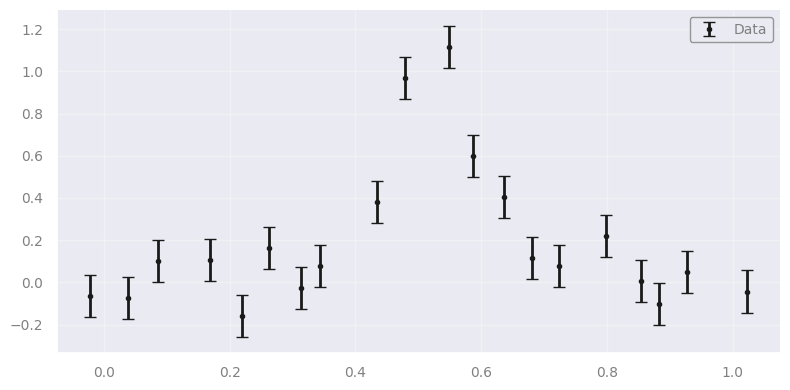

In [3]:
np.random.seed(2024)

def make_data(x, model_dist, amplitude, location, width, error_scale=0.0):
    """Make a spectral line following the PDF of a given distribution.

    x           : the wavelength
    model_dist  : the distribution of which the PDF will be used
    amplitude   : the maximum height of the spectral line
    location    : the center of the spectral line
    width       : the width of the spectral line
    error_scale : the standard deviation of the observational uncertainties

    NOTE: for a noiseless model curve (no observational errors), use the
    `model_prediction` function defined just below instead.

    """
    distribution = model_dist(loc=location, scale=width)
    y = distribution.pdf(x)
    y = amplitude * y / np.max(y)
    if error_scale > 0:
        y = np.random.normal(y, scale=error_scale)
    y_err = np.ones_like(y) * error_scale
    return y, y_err


def model_prediction(x, model_dist, amplitude, location, width):
    # Just like `make_data` above, but without observational errors:
    # it returns only the (noiseless) model curve.
    distribution = model_dist(loc=location, scale=width)
    y = distribution.pdf(x)
    y = amplitude * y / np.max(y)
    return y


n_data = 20

# two potential distributions
model_distributions = [st.cauchy, st.norm]
model_distributions_names = ["Cauchy", "Normal"]

# select pseudo-randomly the true distribution
random_index = 2023 % 17 % 2
true_model_distribution = model_distributions[random_index]
true_model_distribution_name = model_distributions_names[random_index]

# Permitted ranges for the parameters (because we processed the data and we have some intuition)
MIN_AMPLITUDE = 0.9
MAX_AMPLITUDE = 1.1
MIN_LOCATION = 0.45
MAX_LOCATION = 0.55
MIN_WIDTH = 0.05
MAX_WIDTH = 0.15

# Select the true parameters (these are supposed to be hidden from us)
true_amplitude = np.random.uniform(MIN_AMPLITUDE, MAX_AMPLITUDE)
true_location = np.random.uniform(MIN_LOCATION, MAX_LOCATION)
true_width = np.random.uniform(MIN_WIDTH, MAX_WIDTH)

# Make the new data according to the true model
x_data = np.linspace(0.0, 1.0, n_data) + np.random.uniform(-0.5/n_data, 0.5/n_data, size=n_data)
y_data, e_data = make_data(x_data, true_model_distribution, amplitude=true_amplitude, location=true_location, width=true_width, error_scale=0.1)

# Plot them!
plt.figure()
plt.errorbar(x_data, y_data, yerr=e_data, fmt="k.", capsize=4, label="Data")
plt.legend(loc="upper right")
plt.show()

## 1.2. Overplotting two potential models using fiducial parameters


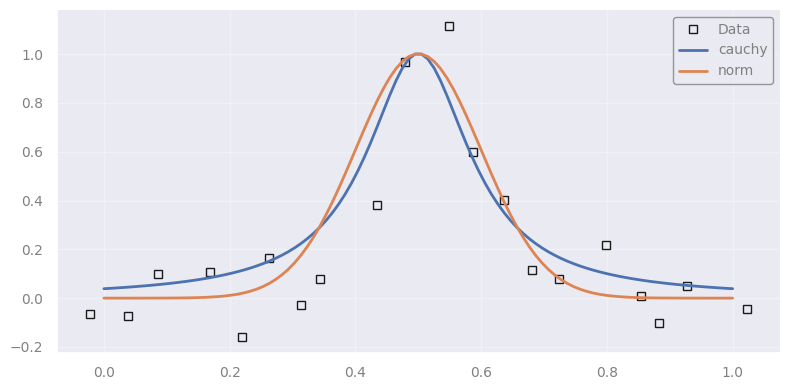

In [4]:
# use the midpoints of the permitted ranges of the parameters
fiducial_amplitude = (MIN_AMPLITUDE + MAX_AMPLITUDE) / 2.0
fiducial_location = (MIN_LOCATION + MAX_LOCATION) / 2.0
fiducial_width = (MIN_WIDTH + MAX_WIDTH) / 2.0

plt.figure()
plt.plot(x_data, y_data, "ks", mfc="none", label="Data")

for model_distribution in model_distributions:
    x_plot = np.linspace(0, 1, 100)

    # the model curve at the fiducial parameters (no observational errors)
    y_plot = model_prediction(x_plot,
                              model_distribution,            # try this model
                              amplitude=fiducial_amplitude,  # fiducial...
                              location=fiducial_location,    # ...parameters...
                              width=fiducial_width)          # ...from ranges
    plt.plot(x_plot, y_plot, label=model_distribution.name)

plt.legend(loc="upper right")
plt.show()

<u>**In-class discussion: The plotted models use fiducial values for the parameters. However, do you think one fits better than the other?**</u>

_Discuss with your teammate, then report._

<details>
<summary><b>[Spoiler]</b></summary>
<br>
It's purely subjective at this point!
<br>
</details>

## 1.3. Defining the prior, likelihood and posterior assuming Gaussian profile...

**Reminder**: we operate in log-space (log-prior, log-likelihood, log-posterior) for numerical reasons.

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Exercise 1.** Complete the prior, likelihood, and posterior functions. Hint: use the `model_prediction` function to get the model curve at the data points.

*(Solution at the end of the notebook.)*

</div>

**(Reminder) From cell above:**
```python
# Permitted ranges for the parameters (because we processed the data and we have some intuition)
MIN_AMPLITUDE = 0.9
MAX_AMPLITUDE = 1.1
MIN_LOCATION = 0.45
MAX_LOCATION = 0.55
MIN_WIDTH = 0.05
MAX_WIDTH = 0.15

# Our observed data
x_data = np.linspace(0.0, 1.0, n_data) + np.random.uniform(-0.5/n_data, 0.5/n_data, size=n_data)
y_data, e_data = make_data(x_data, true_model_distribution, amplitude=true_amplitude, location=true_location, width=true_width, error_scale=0.1)
```

**(Reminder):**

Under the assumption of Gaussian uncertainties and independence of data,

$$
\ln L = \text{constant} - \frac{1}{2} \sum_{i=1}^{N} {\dfrac{(y_i-f(x_i))^2}{\sigma_i^2}} = \text{constant} - \frac{\chi^2}{2}
$$


In [13]:
model_distributions[1]

In [25]:
def ln_prior(amplitude, location, width):
    # Flat (uniform) prior: constant log-probability inside the permitted
    # parameter ranges, and "forbidden" outside them.
    if MIN_AMPLITUDE < amplitude < MAX_AMPLITUDE and MIN_LOCATION < location < MAX_LOCATION and MIN_WIDTH < width < MAX_WIDTH:
        return 0   # inside the allowed box: a flat prior is constant (the log of a constant)
    return -np.inf       # outside the box: probability zero -> what is log(0)?

def ln_likelihood_norm(amplitude, location, width):
    # 1. Model prediction at the data points x_data, using the Normal model.
    y_pred = model_prediction(x_data,
                              st.norm,
                              amplitude=amplitude,
                              location=location,
                              width=width)
    # 2. Chi-squared: sum over data points of (data - model)^2 / error^2
    chi2 = np.sum((y_data-y_pred)**2/(e_data**2))
    # 3. For Gaussian errors:  ln L = constant - chi2 / 2
    return -chi2/2

def ln_posterior_norm(amplitude, location, width):
    # In log-space, what's the (unnormalised) posterior?
    return ln_prior(amplitude, location, width)+ln_likelihood_norm(amplitude, location, width)

## 1.4. Maximizing the posterior

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Exercise 2.**
1. Define the function to be minimized in order to maximize the posterior.
2. Choose appropriate starting values for the minimization routine.

*(Solution at the end of the notebook.)*

</div>

In [26]:
def neg_ln_posterior_norm(theta):
    amplitude, location, width = theta
    return -1*ln_posterior_norm(amplitude, location, width) # what do we want to minimize?

min_result_norm = minimize(neg_ln_posterior_norm, x0=[fiducial_amplitude,fiducial_location,fiducial_width], method='Nelder-Mead')
est_amplitude, est_location, est_width = min_result_norm.x


print(min_result_norm)
print()
print("| PARAMETER  |  ESTIMATION  |  TRUTH  |")
print(f"| amplitude  | {est_amplitude:11.3f}  | {true_amplitude:6.3f}  |")
print(f"| location   | {est_location:11.3f}  | {true_location:6.3f}  |")
print(f"| width      | {est_width:11.3f}  | {true_width:6.3f}  |")
print()
print("At best-fitting values...")
lnL_norm = ln_likelihood_norm(*min_result_norm.x)
lnP_norm = ln_posterior_norm(*min_result_norm.x)
print(f"  * log-prior      : {ln_prior(*min_result_norm.x):.6f}")
print(f"  * log-likelihood : {lnL_norm:.6f}")
print(f"  * log-posterior  : {lnP_norm:.6f}")

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 10.027436499340382
             x: [ 1.068e+00  5.244e-01  6.749e-02]
           nit: 66
          nfev: 122
 final_simplex: (array([[ 1.068e+00,  5.244e-01,  6.749e-02],
                       [ 1.068e+00,  5.244e-01,  6.749e-02],
                       [ 1.068e+00,  5.244e-01,  6.750e-02],
                       [ 1.068e+00,  5.244e-01,  6.750e-02]]), array([ 1.003e+01,  1.003e+01,  1.003e+01,  1.003e+01]))

| PARAMETER  |  ESTIMATION  |  TRUTH  |
| amplitude  |       1.068  |  1.018  |
| location   |       0.524  |  0.520  |
| width      |       0.067  |  0.069  |

At best-fitting values...
  * log-prior      : 0.000000
  * log-likelihood : -10.027436
  * log-posterior  : -10.027436


<u>**In-class discussion: The fit was successful and we got parameters close to the truth. Is the Gaussian model validated?**</u>

_Discuss with your teammate, then report._

<details>
<summary><b>[Spoiler]</b></summary>
<br>
As in hypothesis testing, the model is assumed to be true. The fitting process does not validate the model. The value of the log-posterior does not convey any information regarding the validity of the model.
<br>
</details>

## 1.5. Repeating using a Cauchy profile


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Exercise 3.**  Do the same steps for the Cauchy profile.
    
1. Complete the functions.
2. Choose appropriate starting values for the minimization routine.

*(Solution at the end of the notebook.)*

</div>

In [41]:
def ln_likelihood_cauchy(amplitude, location, width):
    y_pred = model_prediction(x_data,
                              st.cauchy,
                              amplitude=amplitude,
                              location=location,
                              width=width)
    # 2. Chi-squared: sum over data points of (data - model)^2 / error^2
    chi2 = np.sum((y_data-y_pred)**2/(e_data**2))
    # 3. For Gaussian errors:  ln L = constant - chi2 / 2
    return chi2/2

def ln_posterior_cauchy(amplitude, location, width):
    return ln_prior(amplitude, location, width)+ln_likelihood_cauchy(amplitude, location, width)

def neg_ln_posterior_cauchy(theta):
    amplitude, location, width = theta
    return -1*ln_posterior_cauchy(amplitude=amplitude, location=location, width=width) # what do we want to minimize?

min_result_cauchy = minimize(neg_ln_posterior_cauchy, x0=[fiducial_amplitude,fiducial_location,fiducial_width], method='Nelder-Mead')
est_amplitude, est_location, est_width = min_result_cauchy.x

print(min_result_cauchy)
print()
print("| PARAMETER  |  ESTIMATION  |  TRUTH  |")
print(f"| amplitude  | {est_amplitude:11.3f}  | {true_amplitude:6.3f}  |")
print(f"| location   | {est_location:11.3f}  | {true_location:6.3f}  |")
print(f"| width      | {est_width:11.3f}  | {true_width:6.3f}  |")
print()
print("At best-fitting values...")
lnL_cauchy = ln_likelihood_cauchy(*min_result_cauchy.x)
lnP_cauchy = ln_posterior_cauchy(*min_result_cauchy.x)
print(f"  * log-prior      : {ln_prior(*min_result_cauchy.x):.6f}")
print(f"  * log-likelihood : {lnL_cauchy:.6f}")
print(f"  * log-posterior  : {lnP_cauchy:.6f}")

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -79.39023156673092
             x: [ 1.100e+00  4.500e-01  1.152e-01]
           nit: 128
          nfev: 248
 final_simplex: (array([[ 1.100e+00,  4.500e-01,  1.152e-01],
                       [ 1.100e+00,  4.500e-01,  1.152e-01],
                       [ 1.100e+00,  4.500e-01,  1.152e-01],
                       [ 1.100e+00,  4.500e-01,  1.152e-01]]), array([-7.939e+01, -7.939e+01, -7.939e+01, -7.939e+01]))

| PARAMETER  |  ESTIMATION  |  TRUTH  |
| amplitude  |       1.100  |  1.018  |
| location   |       0.450  |  0.520  |
| width      |       0.115  |  0.069  |

At best-fitting values...
  * log-prior      : 0.000000
  * log-likelihood : 79.390232
  * log-posterior  : 79.390232


<u>**In-class discussion: What can you infer from the comparison between the results when assuming normal vs. Cauchy?**</u>

_Discuss with your teammate, then report._

<details>
<summary><b>[Spoiler]</b></summary>
<br>
The parameters are in both cases close to the truth. Whether they are closer or not, in practice, we cannot tell with real data because we don't know the truth!
The likelihood and posterior are, however, different! Maybe we can use this?
<br>
</details>

# 2. Selecting models

If we don't know which model is correct for the data ($D$), we have a **model selection** problem. The first step is to write down the models worth considering — at least the ones suggested by our prior experience and by our understanding of the mechanism that produced the data.

Here we have two: the Normal and the Cauchy model. Let's call them A and B. A natural way to compare them is the ratio of their posteriors:

Posterior odds: $ \dfrac{P(A|D)}{P(B|D)} $

Using Bayes' rule, this becomes:

$$ \dfrac{P(A|D)}{P(B|D)} = \dfrac{P(D|A)P(A) / P(D)}{P(D|B)P(B) / P(D)} = \dfrac{P(D|A)P(A)}{P(D|B)P(B)}$$

## 2.1. Likelihood ratio (prior-independent)

The posterior odds still depend on our prior beliefs about the models, $P(A)$ and $P(B)$. Often we prefer to stay neutral and give both the same prior; these then cancel, leaving just:

$$ \dfrac{P(D|A)}{P(D|B)} $$

**Frequentists** use the same idea under the name **likelihood ratio statistic**:

$$ \mathrm{LR}_{AB} = \dfrac{L_A}{L_B} = e^{l_A - l_B} $$

where $l_A$ and $l_B$ are the log-likelihoods.

> The larger the likelihood ratio, the more Model A is preferred over Model B.


### Connection to comparison of $\chi^2$ values

Under the assumption of Gaussian errors, the log-likelihood is *(some constant)* $-\chi^2/2$. So if we plug in the $\chi^2$ of the best-fit parameters for models A and B, the likelihood ratio becomes:

$$ \mathrm{LR}_{AB} = e^{l_A - l_B} = e^{(-\chi_A^2+\chi_B^2)/2} $$

i.e. the model with the smaller $\chi^2$ is preferred.

## 2.2. Taking into account the flexibility of the models

A more flexible model (more free parameters) can almost always reach a lower $\chi^2$, even when it isn't the true model — so comparing raw $\chi^2$ is unfair. In classical statistics we instead use the **reduced $\chi^2$**: the $\chi^2$ divided by the degrees of freedom (number of data points - number of parameters), which penalises that extra flexibility. Bayesian statistics offers several tools in the same spirit:

### The Akaike Information Criterion

Whenever we represent the data with a model, we throw some information away. There is structure/noise/etc. that we have lost! The **AIC** estimates how much — relative to the other models we are comparing:

$$
\text{AIC} = 2k - 2\ln L
$$

where $k$ is the number of free parameters and $L$ is the likelihood of the data under the model. The $-2\ln L$ term rewards a good fit; the $2k$ term penalises a model for using more parameters. (Information-theoretically, this "lost information" is the Kullback–Leibler divergence between the model and the true data-generating process, the same notion of information as *Shannon's entropy*.)

> The larger the AIC, the more information is lost, so the worse the model.


#### $k$ is a penalty term

With enough parameters (a 100-degree polynomial, say, or a $k$-nearest-neighbour interpolator) we could fit *every* wiggle in the data. But that just hides the information inside the parameters; it would not be fair to judge such a model against a simple linear one on fit quality alone. The $2k$ term is what levels the playing field.

### The Bayesian Information Criterion

$$
\text{BIC} = k \ln N - 2\ln L
$$

where $N$ is the number of data points used to compute the likelihood. The BIC has the same form as the AIC but replaces the penalty $2k$ with $k \ln N$. Since $\ln N > 2$ once $N > 7$, the BIC punishes extra parameters more harshly than the AIC for any realistic dataset, so it tends to favour simpler models. (Which one to use is a long-running debate. Roughly, the AIC aims at predictive accuracy, the BIC at recovering the "true" model.)

> As with the AIC, the larger the BIC, the worse the model.


### Bayes Factors

The **Bayes factor** is like the likelihood ratio, but instead of the best-fit likelihood it uses the *evidence*: the likelihood averaged over *all* possible parameter values $\theta$ (which may differ between models):

$$
\text{K} = \dfrac{P(D|A)}{P(D|B)} = \dfrac{\int P(\theta_A) P(D|\theta_A, A) d\theta} {\int P(\theta_B) P(D|\theta_B, B) d\theta}
$$

> As with the likelihood ratio, the larger the value, the more Model A is preferred over Model B.


### The Jeffreys' scale

| Bayes Factor | Strength of evidence |
| --- | --- |
|  1 - 3.2 | Not worth more than a bare mention |
|  3.2 - 10 | Substantial |
|  10 - 100 | Strong |
|  >100 | Decisive |


## 2.3. Let's compare the AICs, BICs

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Exercise 4.**  Calculate the AICs and BICs, and decide which model *won*!

*(Solution at the end of the notebook.)*

</div>

In [36]:
k=3
AIC_norm = 2*(3-lnL_norm)
AIC_cauchy = 2*(3-lnL_cauchy)

BIC_norm = 3*np.log(20)-2*lnL_norm
BIC_cauchy = 3*np.log(20)-2*lnL_cauchy

print("AIC (norm, cauchy):", AIC_norm, AIC_cauchy)
print("BIC (norm, cauchy):", BIC_norm, BIC_cauchy)
print("Posterior ratio (norm / cauchy)  =", np.exp(lnP_norm - lnP_cauchy))
print("Posterior ratio (cauchy / norm)  =", np.exp(lnP_cauchy - lnP_norm))

print("And the truth is.... (drum roll)... The", true_model_distribution_name, "distribution!")

AIC (norm, cauchy): 26.054872998680764 -152.78046313346184
BIC (norm, cauchy): 29.042069819342736 -149.79326631279986
Posterior ratio (norm / cauchy)  = 1.4668988707586664e-39
Posterior ratio (cauchy / norm)  = 6.81710252788462e+38
And the truth is.... (drum roll)... The Cauchy distribution!


# 3. Helping model selection

<u>**In-class discussion: What could you change to increase the contrast between the models??**</u>

_Discuss with your teammate, then report._

<details>
<summary><b>[Spoiler]</b></summary>
<br>
Since the models cannot change, data have to. Only if we get more data we can be more confident in selecting models. Increase the size of the synthetic data and try again!
<br>
</details>

# 4. Computing the Bayes Factor ⏭️ *(optional / bonus)*

> **Optional — we'll likely skip this in class.** What a Bayes factor *is* was covered in Section 2; this section shows how to actually *compute* one, via Monte Carlo integration. Work through it on your own if you'd like to go further.

Bayes Factors are agnostic about the location of the posterior maximum! They use the *marginal likelihood* or the *evidence*: the integral of the likelihood over all possible values of the parameters.

This makes them hard to compute, especially in complex, multi-dimensional parameter spaces. Thankfully, there are techniques like **Monte Carlo integration** that can help us.

Essentially, instead of integrating a function over $x$, we use the sum of uniform samples of $x$:

$$ \int\limits_a^b f(x) dx \approx \frac{b-a}{N} \sum\limits_{i=1}^N f(x_i) $$

or in $k$ dimensions, a sum over the whole volume $V$ of the multi-dimensional parameter space $\Omega$:

$$ \int_\Omega f(\vec{x}) d\vec{x} \approx \frac{V}{N} \sum\limits_{i=1}^N f(\vec{x}_i)$$

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Exercise 5.**
    
1. Choose a sample size for the Monte Carlo calculation.
2. Calculate the Bayes factor.
3. Which model is preferred? Does this agree with AIC and BIC?

*(Solution at the end of the notebook.)*

</div>

In [ ]:
sample_size = ...
amp_samples = np.random.uniform(MIN_AMPLITUDE, MAX_AMPLITUDE, size=sample_size)
loc_samples = np.random.uniform(MIN_LOCATION, MAX_LOCATION, size=sample_size)
wid_samples = np.random.uniform(MIN_WIDTH, MAX_WIDTH, size=sample_size)

# use no normalization factor (watch out for the NaNs)
ln_norm_factor = 0.0
print("Normalization factor:", ln_norm_factor)

sum_norm = 0.0
sum_cauchy = 0.0

for amp, loc, wid in zip(amp_samples, loc_samples, wid_samples):
    sum_norm += ...
    sum_cauchy += ...

K = sum_norm / sum_cauchy
print(f"K (norm / cauchy): {K:.4g}")
print(f"K (cauchy / norm): {1.0/K:.4g}")

# 5. Discussion: Bayesian vs. Frequentist

<u>**In-class discussion: What are the main differences between the two approaches? Which one we prefer in astronomy/cosmology?**</u>


### 5.1. Philosophical foundations

| Aspect                   | Frequentist                                   | Bayesian                                         |
| ------------------------ | --------------------------------------------- | ------------------------------------------------ |
| **What is probability?** | Long-run frequency in repeated experiments    | Degree of belief, given current information      |
| **Unknown parameters**   | Fixed but unknown                             | Random variables with probability distributions  |
| **Data**                 | Random (from repeated sampling)               | Fixed (once observed)                            |
| **Goal**                 | Procedures that perform well under repetition | Reasonable inference given the data at hand      |

* A **frequentist** asks: *"How would this method perform if I repeated the experiment many times?"*
* A **Bayesian** asks: *"Given the data I actually observed, what do I believe about the parameters?"*

---

### 5.2. Priors: the core divergence

The defining difference is the **prior**:

* **Bayesian**: introduces a prior to encode existing knowledge (or ignorance).
* **Frequentist**: allows no prior; everything must come from the data.

Is that a strength or a weakness?

* **Bayesian view**: a prior makes assumptions *explicit*, and assumptions are always present, stated or not.
* **Frequentist view**: a prior injects subjectivity and makes results less "objective".

>**Thought experiment — the librarian vs. the farmer**
>
> Someone is shy, bookish, and wears glasses. Librarian or farmer?
> The *likelihood* favours librarian (it fits the stereotype), but the *prior* says there are far more farmers than librarians.
> ➡ Ignore the base rate and you guess librarian; account for it (Bayes) and farmer becomes far more likely.

Sometimes the data alone aren't enough — especially for rare events. And in astronomy **priors are often genuinely available** (stellar populations, known cosmological parameters, brightness ranges, …).

---

### 5.3. Interpreting the results

This is where the two are most often confused:

| Quantity        | Frequentist meaning                                                                      | Bayesian meaning                                                                                |
| --------------- | ---------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------- |
| 95% interval    | "Over many repeats, 95% of such intervals contain the true value." (*confidence* interval) | "Given this data, there is a 95% probability the true value is in this interval." (*credible* interval) |
| Hypothesis test | p-value: probability of data at least this extreme *if the null is true*                 | posterior probability of the hypothesis itself                                                  |

* A **confidence interval** is *not* a **credible interval**.
* A **p-value** is *not* the probability that a hypothesis is true.

These are the two most common misreadings in the literature.

---

### 5.4. Why astronomy leans Bayesian

1. **Unrepeatable experiments.** We observe *one* universe, *one* supernova, *one* lens system. There is no ensemble of repeats for the frequentist long-run argument to refer to. Bayesian inference reasons directly about the single dataset we actually have.

2. **Complex models.** Hierarchical models, forward models and simulators are the norm in astrophysics. The Bayesian machinery (priors, marginalisation over nuisance parameters, MCMC / nested sampling) handles them in one consistent framework.

3. **Incomplete data and selection effects.** Real surveys censor, truncate and select (e.g. Malmquist bias). These can be written directly into the likelihood and priors, so the inference accounts for *how* the data were gathered, not just their values.

4. **Combining datasets.** Today's posterior is tomorrow's prior. This gives us a principled way to fold in independent measurements and let knowledge propagate between instruments (e.g. Gaia + JWST + Euclid).

5. **Full uncertainty quantification.** A posterior is a whole distribution, capturing correlations, asymmetries and multiple modes: far more than a point estimate with a single error bar, and essential when parameters are degenerate.

6. **Model comparison.** Bayes factors (and the AIC/BIC we used in Sections 2 and 4) compare entire models while penalising overfitting, letting us ask not just *what* the parameters are, but *which model* the data prefer.

<table><tr>
<td> <img src="https://raw.githubusercontent.com/AstroStat-Academy/astrostat-school-8/main/Bayesian/images/frequentists_vs_bayesians.png" style="height:700px;"/> </td>
<td> <img src="https://raw.githubusercontent.com/AstroStat-Academy/astrostat-school-8/main/Bayesian/images/modified_bayes_theorem.png" style="height: 300px;"/> </td>
</tr></table>


# Solutions

> Try each exercise yourself before looking here! These are the reference solutions for all exercises, in order.

### Exercise 1 — Prior, likelihood and posterior

In [37]:
def ln_prior(amplitude, location, width):
    if MIN_AMPLITUDE < amplitude < MAX_AMPLITUDE and MIN_LOCATION < location < MAX_LOCATION and MIN_WIDTH < width < MAX_WIDTH:
        return 0.0
    return -np.inf

def ln_likelihood_norm(amplitude, location, width):
    y_pred = model_prediction(x_data, st.norm, amplitude, location, width)
    chi2 = np.sum((y_data - y_pred) ** 2.0 / e_data ** 2.0)
    return -chi2 / 2.0

def ln_posterior_norm(amplitude, location, width):
    return ln_prior(amplitude, location, width) + ln_likelihood_norm(amplitude, location, width)

### Exercise 2 — Maximising the posterior

In [38]:
def neg_ln_posterior_norm(theta):
    amplitude, location, width = theta
    return -ln_posterior_norm(amplitude=amplitude, location=location, width=width)

min_result_norm = minimize(neg_ln_posterior_norm, x0=[fiducial_amplitude, fiducial_location, fiducial_width], method='Nelder-Mead')
est_amplitude, est_location, est_width = min_result_norm.x


print(min_result_norm)
print()
print("| PARAMETER  |  ESTIMATION  |  TRUTH  |")
print(f"| amplitude  | {est_amplitude:11.3f}  | {true_amplitude:6.3f}  |")
print(f"| location   | {est_location:11.3f}  | {true_location:6.3f}  |")
print(f"| width      | {est_width:11.3f}  | {true_width:6.3f}  |")
print()
print("At best-fitting values...")
lnL_norm = ln_likelihood_norm(*min_result_norm.x)
lnP_norm = ln_posterior_norm(*min_result_norm.x)
print(f"  * log-prior      : {ln_prior(*min_result_norm.x):.6f}")
print(f"  * log-likelihood : {lnL_norm:.6f}")
print(f"  * log-posterior  : {lnP_norm:.6f}")

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 10.027436499340382
             x: [ 1.068e+00  5.244e-01  6.749e-02]
           nit: 66
          nfev: 122
 final_simplex: (array([[ 1.068e+00,  5.244e-01,  6.749e-02],
                       [ 1.068e+00,  5.244e-01,  6.749e-02],
                       [ 1.068e+00,  5.244e-01,  6.750e-02],
                       [ 1.068e+00,  5.244e-01,  6.750e-02]]), array([ 1.003e+01,  1.003e+01,  1.003e+01,  1.003e+01]))

| PARAMETER  |  ESTIMATION  |  TRUTH  |
| amplitude  |       1.068  |  1.018  |
| location   |       0.524  |  0.520  |
| width      |       0.067  |  0.069  |

At best-fitting values...
  * log-prior      : 0.000000
  * log-likelihood : -10.027436
  * log-posterior  : -10.027436


### Exercise 3 — Cauchy profile

In [39]:
def ln_likelihood_cauchy(amplitude, location, width):
    y_pred = model_prediction(x_data, st.cauchy, amplitude, location, width)
    chi2 = np.sum((y_data - y_pred) ** 2.0 / e_data ** 2.0)
    return -chi2 / 2.0

def ln_posterior_cauchy(amplitude, location, width):
    return ln_prior(amplitude, location, width) + ln_likelihood_cauchy(amplitude, location, width)

def neg_ln_posterior_cauchy(theta):
    amplitude, location, width = theta
    return -ln_posterior_cauchy(amplitude=amplitude, location=location, width=width)

min_result_cauchy = minimize(neg_ln_posterior_cauchy, x0=[fiducial_amplitude, fiducial_location, fiducial_width], method='Nelder-Mead')
est_amplitude, est_location, est_width = min_result_cauchy.x

print(min_result_cauchy)
print()
print("| PARAMETER  |  ESTIMATION  |  TRUTH  |")
print(f"| amplitude  | {est_amplitude:11.3f}  | {true_amplitude:6.3f}  |")
print(f"| location   | {est_location:11.3f}  | {true_location:6.3f}  |")
print(f"| width      | {est_width:11.3f}  | {true_width:6.3f}  |")
print()
print("At best-fitting values...")
lnL_cauchy = ln_likelihood_cauchy(*min_result_cauchy.x)
lnP_cauchy = ln_posterior_cauchy(*min_result_cauchy.x)
print(f"  * log-prior      : {ln_prior(*min_result_cauchy.x):.6f}")
print(f"  * log-likelihood : {lnL_cauchy:.6f}")
print(f"  * log-posterior  : {lnP_cauchy:.6f}")

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 8.666009497316683
             x: [ 1.100e+00  5.196e-01  5.715e-02]
           nit: 93
          nfev: 164
 final_simplex: (array([[ 1.100e+00,  5.196e-01,  5.715e-02],
                       [ 1.100e+00,  5.196e-01,  5.715e-02],
                       [ 1.100e+00,  5.196e-01,  5.712e-02],
                       [ 1.100e+00,  5.196e-01,  5.724e-02]]), array([ 8.666e+00,  8.666e+00,  8.666e+00,  8.666e+00]))

| PARAMETER  |  ESTIMATION  |  TRUTH  |
| amplitude  |       1.100  |  1.018  |
| location   |       0.520  |  0.520  |
| width      |       0.057  |  0.069  |

At best-fitting values...
  * log-prior      : 0.000000
  * log-likelihood : -8.666009
  * log-posterior  : -8.666009


### Exercise 4 — AIC and BIC

In [40]:
AIC_norm = 2 * 3 - 2 * lnL_norm
AIC_cauchy = 2 * 3 - 2 * lnL_cauchy

BIC_norm = 3 * np.log(20) - 2 * lnL_norm
BIC_cauchy = 3 * np.log(20) - 2 * lnL_cauchy

print("AIC (norm, cauchy):", AIC_norm, AIC_cauchy)
print("BIC (norm, cauchy):", BIC_norm, BIC_cauchy)
print("Posterior ratio (norm / cauchy)  =", np.exp(lnP_norm - lnP_cauchy))
print("Posterior ratio (cauchy / norm)  =", np.exp(lnP_cauchy - lnP_norm))

print("And the truth is.... (drum roll)... The", true_model_distribution_name, "distribution!")

AIC (norm, cauchy): 26.054872998680764 23.332018994633366
BIC (norm, cauchy): 29.042069819342736 26.319215815295337
Posterior ratio (norm / cauchy)  = 0.25629478270481293
Posterior ratio (cauchy / norm)  = 3.9017571463861915
And the truth is.... (drum roll)... The Cauchy distribution!


### Exercise 5 — Bayes factor (optional)

In [ ]:
sample_size = 10000
amp_samples = np.random.uniform(MIN_AMPLITUDE, MAX_AMPLITUDE, size=sample_size)
loc_samples = np.random.uniform(MIN_LOCATION, MAX_LOCATION, size=sample_size)
wid_samples = np.random.uniform(MIN_WIDTH, MAX_WIDTH, size=sample_size)

# use no normalization factor (watch out for the NaNs)
# ln_norm_factor = 0.0
# use the first random point to get the normalization factor
ln_norm_factor = ln_likelihood_norm(amp_samples[0], loc_samples[0], wid_samples[0])
print("Normalization factor:", ln_norm_factor)

sum_norm = 0.0
sum_cauchy = 0.0

for amp, loc, wid in zip(amp_samples, loc_samples, wid_samples):
    sum_norm += np.exp(ln_likelihood_norm(amp, loc, wid) - ln_norm_factor)
    sum_cauchy += np.exp(ln_likelihood_cauchy(amp, loc, wid) - ln_norm_factor)

K = sum_norm / sum_cauchy
print(f"K (norm / cauchy): {K:.4g}")
print(f"K (cauchy / norm): {1.0/K:.4g}")

In [ ]:
###EOF